<a href="https://colab.research.google.com/github/sachinkumarcgc0012/Data-science-Training-/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
pd.read_csv("/content/drive/MyDrive/netflix_users.csv")

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14
...,...,...,...,...,...,...,...,...
24995,24996,David Miller,18,Australia,Premium,183.88,Horror,2025-01-18
24996,24997,Jane Miller,17,USA,Premium,112.37,Drama,2024-06-29
24997,24998,Sarah Miller,14,USA,Premium,351.80,Action,2024-10-16
24998,24999,Michael Williams,71,USA,Basic,655.89,Action,2024-08-27


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/netflix_users.csv")

# 1. Basic information
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

# 2. First and last rows
print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

# 3. Dataset summary
print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

# 4. Missing values
print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
print((df.isnull().sum() / len(df)) * 100)

# 5. Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# 6. Unique values in categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"\n--- {col} ---")
    print("Unique Values:", df[col].nunique())
    print(df[col].value_counts().head(10))

# 7. Numerical columns summary
num_cols = df.select_dtypes(include=np.number).columns

print("\nNumerical Columns:")
print(num_cols.tolist())

# 8. Correlation
if len(num_cols) > 1:
    print("\nCorrelation Matrix:")
    print(df[num_cols].corr())

# 9. Check for outliers using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Shape: (25000, 8)

Columns:
['User_ID', 'Name', 'Age', 'Country', 'Subscription_Type', 'Watch_Time_Hours', 'Favorite_Genre', 'Last_Login']

Data Types:
User_ID                int64
Name                  object
Age                    int64
Country               object
Subscription_Type     object
Watch_Time_Hours     float64
Favorite_Genre        object
Last_Login            object
dtype: object

First 5 rows:
   User_ID            Name  Age Country Subscription_Type  Watch_Time_Hours  \
0        1  James Martinez   18  France           Premium             80.26   
1        2     John Miller   23     USA           Premium            321.75   
2        3      Emma Davis   60      UK             Basic             35.89   
3        4     Emma Miller   44     USA           Premium            261.56   
4        5      Jane Smith   68     USA          Standard            909.30   

  Favorite_Genre  Last_Login  
0          Drama  2024-05-12  
1         Sci-Fi  2025-02-05  
2         Comedy  2

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/netflix_users.csv")

# 1. Remove duplicate rows
df = df.drop_duplicates()

# 2. Remove extra spaces from column names
df.columns = df.columns.str.strip()

# 3. Fix data types
# Example:
# df['date'] = pd.to_datetime(df['date'])
# df['age'] = pd.to_numeric(df['age'], errors='coerce')

# 4. Handle missing values

# Numerical columns: fill with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns: fill with mode
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 5. Remove rows with too many missing values (optional)
# df = df.dropna(thresh=len(df.columns)*0.7)

# 6. Standardize text columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# 7. Remove outliers using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

# 8. Check final dataset
print("Shape after cleaning:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

# Save cleaned dataset
df.to_csv("cleaned_data.csv", index=False)

print("\nCleaned dataset saved as cleaned_data.csv")

Shape after cleaning: (25000, 8)

Missing values:
User_ID              0
Name                 0
Age                  0
Country              0
Subscription_Type    0
Watch_Time_Hours     0
Favorite_Genre       0
Last_Login           0
dtype: int64

Duplicates: 0

Cleaned dataset saved as cleaned_data.csv


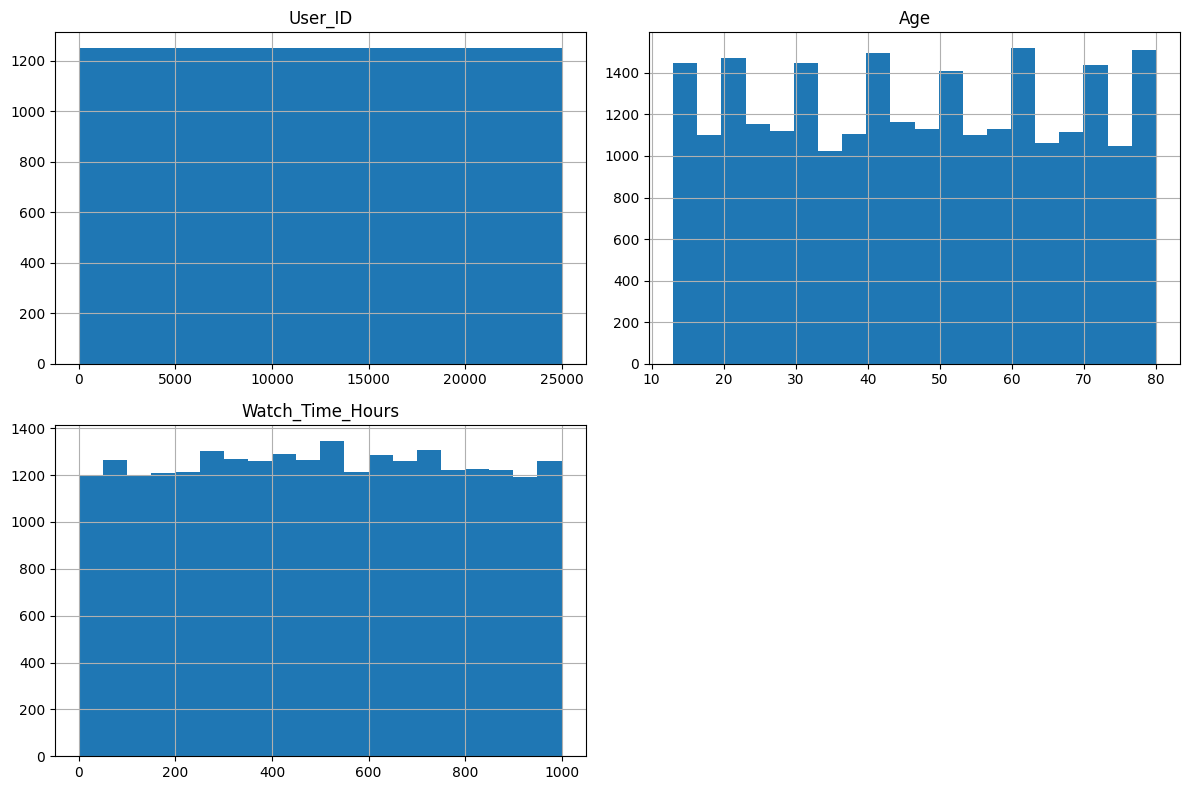

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

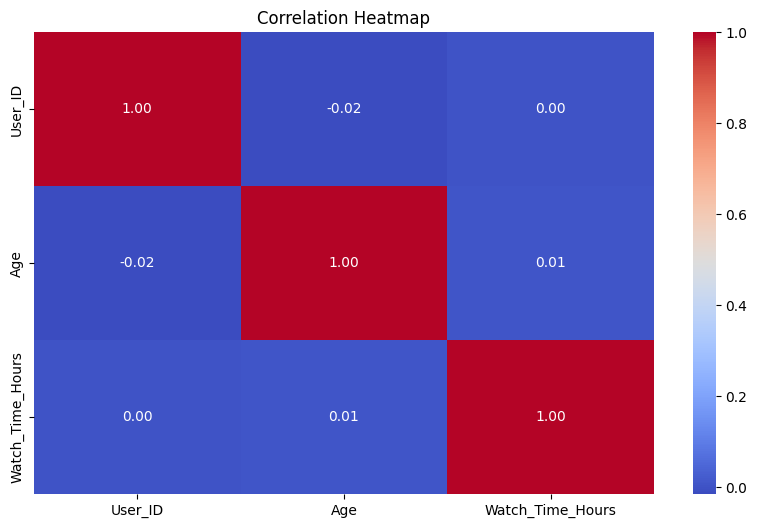

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

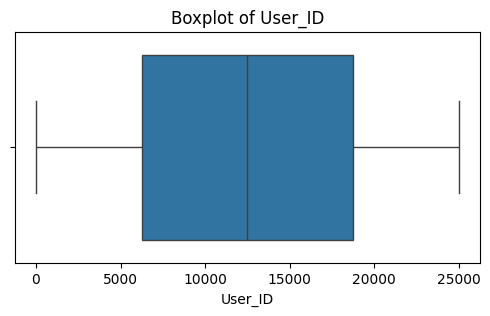

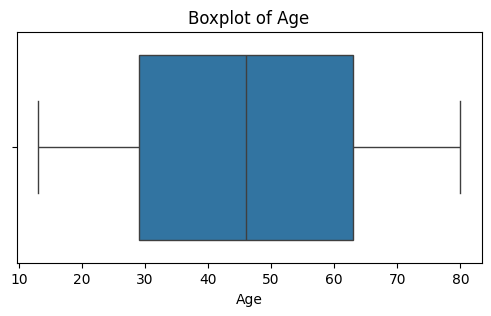

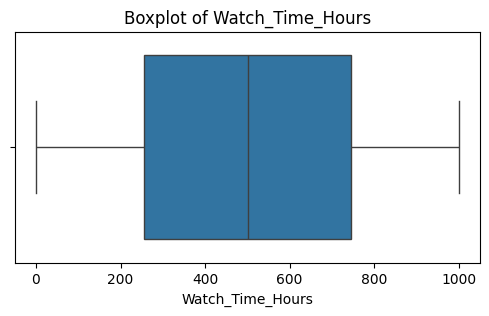

In [ ]:
import seaborn as sns

for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

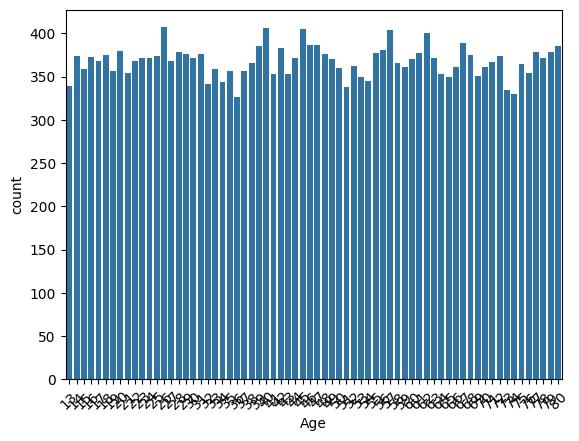

In [ ]:
import seaborn as sns

sns.countplot(data=df, x='Age')
plt.xticks(rotation=45)
plt.show()

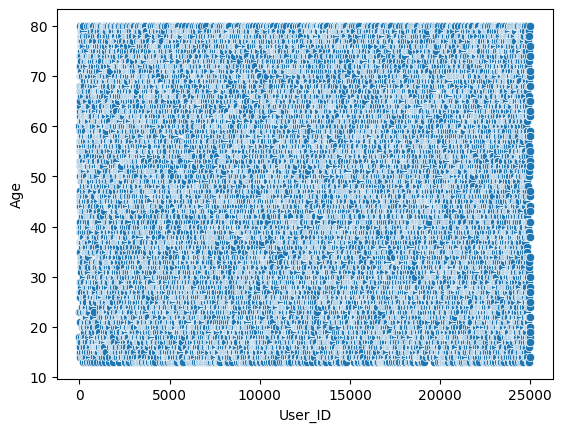

In [ ]:
sns.scatterplot(
    data=df,
    x='User_ID',
    y='Age'
)
plt.show()

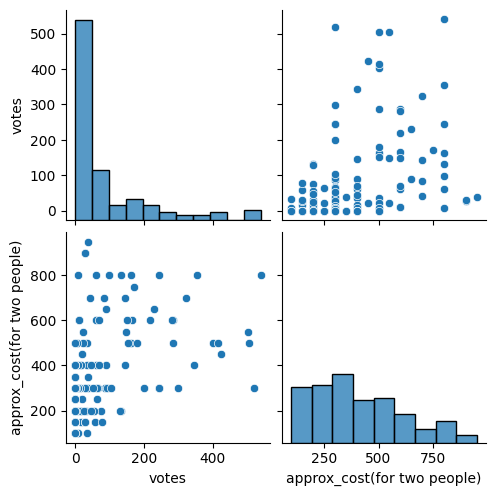

In [ ]:
sns.pairplot(df.select_dtypes(include='number'))
plt.show()

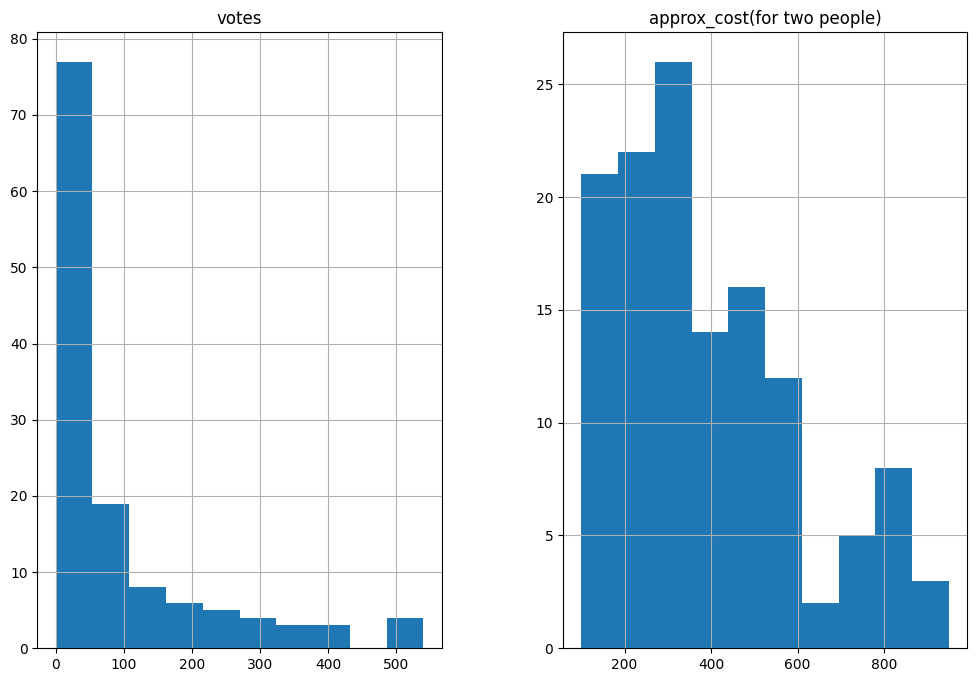

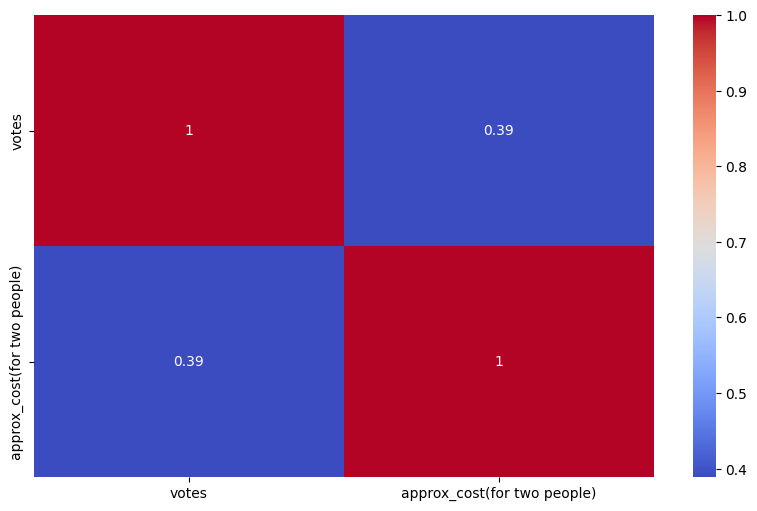

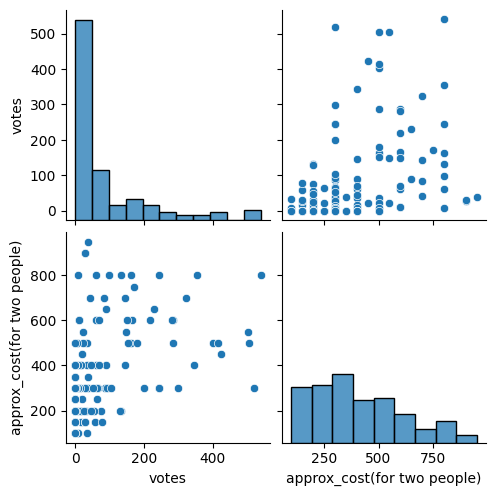

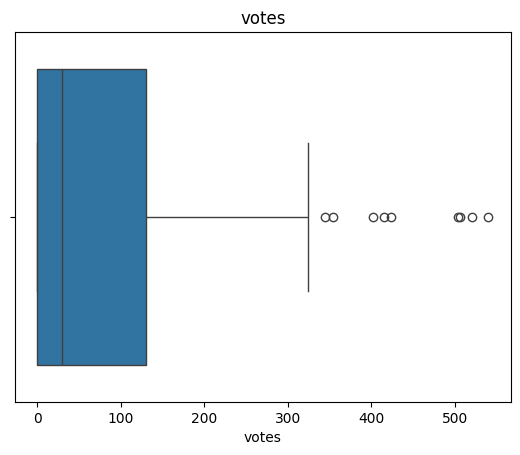

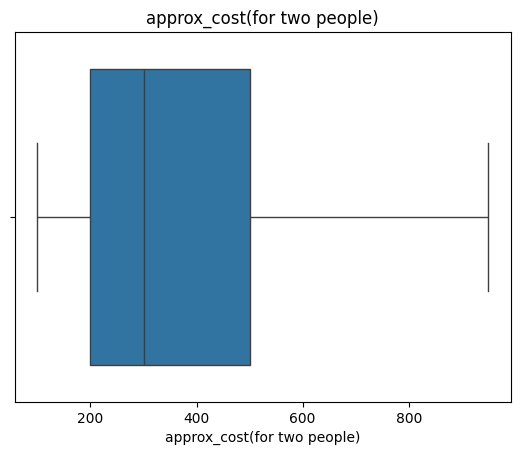

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram
df.hist(figsize=(12,8))
plt.show()

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# Pairplot
sns.pairplot(df.select_dtypes(include='number'))
plt.show()

# Boxplots
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()